# FLAG 2027 — EXP-000c Validated FOP Baseline

This notebook is the **validated Kaggle baseline** for the current FLAG 2027 progress phase.

Authoritative sources:
1. *Fusion and Orthogonal Projection for Improved Face-Voice Association*
2. `https://github.com/msaadsaeed/FOP`
3. `https://github.com/SwapnilKhandoker101/FLAG_2027`
4. FLAG 2027 Evaluation Plan / challenge page

## Empirical CodaBench finding

The same EXP-000c checkpoint was submitted twice:

| Submission score | Overall EER |
|---|---:|
| `- squared_L2` | 57.83% |
| `+ squared_L2` | **42.17%** |

Per-cell raw-distance result:
- no_gender / English: **36.31**
- no_gender / Bangla: **38.98**
- gender / English: **43.38**
- gender / Bangla: **50.00**
- Overall: **42.17**

Therefore, despite the written Evaluation Plan saying "higher score = stronger match",
the **live CodaBench scorer currently behaves with the legacy FOP distance convention**:

> **LOWER submitted score = more likely same speaker**

This notebook therefore:
- uses **negative distance internally** only when computing ROC/EER with `sklearn`;
- writes **raw positive squared-L2 distance** to CodaBench submission files.

> Notebook-first policy remains active. Stable source code should only be updated after the baseline is accepted as final.

## 0. Imports, configuration, reproducibility

In [1]:
from __future__ import annotations

import json
import math
import random
import shutil
import zipfile
from copy import deepcopy
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import roc_curve, roc_auc_score
from tqdm.auto import tqdm

print("torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [2]:
@dataclass
class CFG:
    EXP_ID: str = "EXP-000c-source-faithful"

    SEED: int = 1
    EMBED_DIM: int = 128
    FUSION: str = "gated"

    # Source-faithful FOP sweep from the official README.
    ALPHAS: tuple = (0.0, 0.1, 0.5, 1.0, 2.0, 5.0)
    MAX_EPOCHS: int = 50

    LR: float = 1e-5
    WEIGHT_DECAY: float = 0.01
    BATCH_SIZE: int = 128

    # Participant-side model-selection split because FLAG dev GT is withheld.
    INTERNAL_VAL_SPEAKERS: int = 14      # 56 train speakers / 14 unseen validation speakers
    INTERNAL_NEG_PER_POS: int = 1

    # Fast debug reduces cost but must never be submitted.
    FAST_DEV_RUN: bool = False
    FAST_ALPHAS: tuple = (0.5, 1.0)
    FAST_EPOCHS: int = 3

    NUM_WORKERS: int = 0

    # FOP verification uses squared Euclidean distance. FLAG requires higher=same,
    # so submission score is its negative.
    SCORE_MODE: str = "raw_squared_l2_distance"

cfg = CFG()

if cfg.FAST_DEV_RUN:
    ACTIVE_ALPHAS = cfg.FAST_ALPHAS
    ACTIVE_EPOCHS = cfg.FAST_EPOCHS
else:
    ACTIVE_ALPHAS = cfg.ALPHAS
    ACTIVE_EPOCHS = cfg.MAX_EPOCHS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORKDIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
RUN_DIR = WORKDIR / f"FLAG_2027_{cfg.EXP_ID}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(cfg.SEED)

print(json.dumps(asdict(cfg), indent=2))
print("ACTIVE_ALPHAS:", ACTIVE_ALPHAS)
print("ACTIVE_EPOCHS:", ACTIVE_EPOCHS)
print("DEVICE:", DEVICE)
print("RUN_DIR:", RUN_DIR)

{
  "EXP_ID": "EXP-000c-source-faithful",
  "SEED": 1,
  "EMBED_DIM": 128,
  "FUSION": "gated",
  "ALPHAS": [
    0.0,
    0.1,
    0.5,
    1.0,
    2.0,
    5.0
  ],
  "MAX_EPOCHS": 50,
  "LR": 1e-05,
  "WEIGHT_DECAY": 0.01,
  "BATCH_SIZE": 128,
  "INTERNAL_VAL_SPEAKERS": 14,
  "INTERNAL_NEG_PER_POS": 1,
  "FAST_DEV_RUN": false,
  "FAST_ALPHAS": [
    0.5,
    1.0
  ],
  "FAST_EPOCHS": 3,
  "NUM_WORKERS": 0,
  "SCORE_MODE": "raw_squared_l2_distance"
}
ACTIVE_ALPHAS: (0.0, 0.1, 0.5, 1.0, 2.0, 5.0)
ACTIVE_EPOCHS: 50
DEVICE: cuda
RUN_DIR: /kaggle/working/FLAG_2027_EXP-000c-source-faithful


## 1. Resolve the exact FLAG Kaggle structure

Confirmed user dataset layout:

```text
flag-input/
├── dev_set/
│   └── dev_set/
│       ├── no_gender/
│       └── gender/
└── train_set/
    └── train_set/
        ├── features/
        │   ├── faces/
        │   └── voices/
        └── train_set/
            ├── faces/English/<id>/
            └── voices/English/<id>/
```

In [3]:
KAGGLE_INPUT = Path("/kaggle/input")

def locate_flag_input(root: Path) -> Path:
    candidates = []
    for p in root.rglob("*"):
        if not p.is_dir():
            continue
        if (p / "dev_set/dev_set").is_dir() and (p / "train_set/train_set").is_dir():
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            "Could not find a FLAG root containing both dev_set/dev_set and train_set/train_set."
        )

    candidates = sorted(candidates, key=lambda p: (len(p.parts), str(p)))
    for i, p in enumerate(candidates):
        print(f"[{i}] {p}")
    return candidates[0]

FLAG_INPUT_ROOT = locate_flag_input(KAGGLE_INPUT)
DEV_ROOT = FLAG_INPUT_ROOT / "dev_set/dev_set"
TRAIN_ROOT = FLAG_INPUT_ROOT / "train_set/train_set"

TRAIN_FACE = TRAIN_ROOT / "features/faces/train_English_faces.csv"
TRAIN_VOICE = TRAIN_ROOT / "features/voices/train_English_voices.csv"
TRAIN_LIST = TRAIN_ROOT / "train_set/train_English.txt"

print("FLAG_INPUT_ROOT:", FLAG_INPUT_ROOT)
print("TRAIN_FACE:", TRAIN_FACE)
print("TRAIN_VOICE:", TRAIN_VOICE)
print("TRAIN_LIST:", TRAIN_LIST)

[0] /kaggle/input/datasets/trngsnam/flag-input
FLAG_INPUT_ROOT: /kaggle/input/datasets/trngsnam/flag-input
TRAIN_FACE: /kaggle/input/datasets/trngsnam/flag-input/train_set/train_set/features/faces/train_English_faces.csv
TRAIN_VOICE: /kaggle/input/datasets/trngsnam/flag-input/train_set/train_set/features/voices/train_English_voices.csv
TRAIN_LIST: /kaggle/input/datasets/trngsnam/flag-input/train_set/train_set/train_set/train_English.txt


In [4]:
PROTOCOLS = [
    ("no_gender", "English", "sub_score_v4_English_heard.txt", 1008),
    ("no_gender", "Bangla",  "sub_score_v4_Bangla_unheard.txt", 1406),
    ("gender",    "English", "sub_score_v4_English_heard.txt", 982),
    ("gender",    "Bangla",  "sub_score_v4_Bangla_unheard.txt", 1468),
]

def protocol_paths(track, lang):
    root = DEV_ROOT / track
    return {
        "face": root / "features" / f"{lang}_test_faces.csv",
        "voice": root / "features" / f"{lang}_test_voices.csv",
        "pairs": root / f"{lang}_test.txt",
    }

resolved_protocols = {
    (track, lang): protocol_paths(track, lang)
    for track, lang, _, _ in PROTOCOLS
}

required = [TRAIN_FACE, TRAIN_VOICE, TRAIN_LIST]
for p in resolved_protocols.values():
    required += [p["face"], p["voice"], p["pairs"]]

missing = [p for p in required if not p.exists()]
if missing:
    for p in missing:
        print("MISSING:", p)
    raise FileNotFoundError("FLAG files missing.")

print("✅ All FLAG feature and pair-list files found.")

✅ All FLAG feature and pair-list files found.


## 2. Load and audit training features

In [5]:
def csv_shape_fast(path: Path):
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        first = f.readline().rstrip("\n")
        ncols = first.count(",") + 1
        nrows = 1 + sum(1 for _ in f)
    return nrows, ncols

assert csv_shape_fast(TRAIN_FACE) == (6485, 4097)
assert csv_shape_fast(TRAIN_VOICE) == (6485, 193)

for track, lang, _, n_expected in PROTOCOLS:
    p = resolved_protocols[(track, lang)]
    assert csv_shape_fast(p["face"]) == (n_expected, 4096)
    assert csv_shape_fast(p["voice"]) == (n_expected, 192)

print("✅ Official FLAG-v4 feature dimensions confirmed.")

✅ Official FLAG-v4 feature dimensions confirmed.


In [6]:
face_df = pd.read_csv(TRAIN_FACE, header=None)
voice_df = pd.read_csv(TRAIN_VOICE, header=None)

X_face = face_df.iloc[:, :-1].to_numpy(dtype=np.float32)
X_voice = voice_df.iloc[:, :-1].to_numpy(dtype=np.float32)

face_labels_raw = face_df.iloc[:, -1].astype(str).to_numpy()
voice_labels_raw = voice_df.iloc[:, -1].astype(str).to_numpy()

assert np.array_equal(face_labels_raw, voice_labels_raw), (
    "Face and voice feature rows are not label-aligned."
)

speakers = sorted(np.unique(face_labels_raw).tolist())
assert len(speakers) == 70, len(speakers)

speaker_to_global = {s: i for i, s in enumerate(speakers)}
y_global = np.asarray([speaker_to_global[s] for s in face_labels_raw], dtype=np.int64)

print("face:", X_face.shape)
print("voice:", X_voice.shape)
print("speakers:", len(speakers))
print("samples:", len(y_global))
display(pd.Series(face_labels_raw).value_counts().describe())

face: (6485, 4096)
voice: (6485, 192)
speakers: 70
samples: 6485


count     70.000000
mean      92.642857
std       53.425835
min        2.000000
25%       51.000000
50%       92.000000
75%      131.000000
max      226.000000
Name: count, dtype: float64

## 3. Exact FOP architecture (adapted only where FLAG v4 requires it)

Source-faithful properties from `retrieval_model.py`:

- each modality branch:
  `Linear → BatchNorm1d → ReLU → Dropout(0.5) → L2 normalize`
- gated attention:
  `concat(face,voice) → Linear → BatchNorm → ReLU → Linear → sigmoid`
- modality transforms inside gated fusion use `tanh`
- classifier is applied to the fused representation
- verification compares the returned **face_trans** and **voice_trans**

FLAG-v4-only changes:
- face input: `4096`
- voice input: `192`
- classifier output: number of training identities in the current training partition
- device handling made modern/device-agnostic instead of hardcoded `.cuda()`

In [7]:
class Forward_Block(nn.Module):
    def __init__(self, input_dim=128, output_dim=128, p_val=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(),
            nn.Dropout(p=p_val),
        )

    def forward(self, x):
        return self.block(x)


def make_fc_1d(f_in, f_out):
    return nn.Sequential(
        nn.Linear(f_in, f_out),
        nn.BatchNorm1d(f_out),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
    )


class GatedFusion(nn.Module):
    def __init__(self, embed_dim_in, mid_att_dim, emb_dim_out):
        super().__init__()

        # These are empty Sequential containers in the official source.
        self.linear_face = nn.Sequential()
        self.linear_voice = nn.Sequential()
        self.final_transform = nn.Sequential()

        self.attention = nn.Sequential(
            Forward_Block(embed_dim_in * 2, mid_att_dim),
            nn.Linear(mid_att_dim, emb_dim_out),
        )

    def forward(self, face_input, voice_input):
        concat = torch.cat((face_input, voice_input), dim=1)
        attention_out = torch.sigmoid(self.attention(concat))

        face_trans = torch.tanh(self.linear_face(face_input))
        voice_trans = torch.tanh(self.linear_voice(voice_input))

        out = face_trans * attention_out + (1.0 - attention_out) * voice_trans
        out = self.final_transform(out)

        return out, face_trans, voice_trans


class LinearWeightedAvg(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight1 = nn.Parameter(torch.rand(1))
        self.weight2 = nn.Parameter(torch.rand(1))

    def forward(self, face_feat, voice_feat):
        return (
            self.weight1 * face_feat + self.weight2 * voice_feat,
            face_feat,
            voice_feat,
        )


class EmbedBranch(nn.Module):
    def __init__(self, feat_dim, embedding_dim):
        super().__init__()
        self.fc1 = make_fc_1d(feat_dim, embedding_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = F.normalize(x, p=2, dim=1)
        return x


class FOP(nn.Module):
    def __init__(self, face_feat_dim, voice_feat_dim, num_classes, dim_embed=128, fusion="gated"):
        super().__init__()

        self.voice_branch = EmbedBranch(voice_feat_dim, dim_embed)
        self.face_branch = EmbedBranch(face_feat_dim, dim_embed)

        if fusion == "linear":
            self.fusion_layer = LinearWeightedAvg()
        elif fusion == "gated":
            self.fusion_layer = GatedFusion(dim_embed, 128, dim_embed)
        else:
            raise ValueError(fusion)

        # Official source hardcodes 901 for VoxCeleb1.
        # FLAG adaptation: classifier must match the current training identities.
        self.logits_layer = nn.Linear(dim_embed, num_classes)

    def forward(self, faces, voices):
        voices = self.voice_branch(voices)
        faces = self.face_branch(faces)

        feats, faces, voices = self.fusion_layer(faces, voices)
        logits = self.logits_layer(feats)

        return [feats, logits], faces, voices

    def train_forward(self, faces, voices, labels=None):
        return self(faces, voices)


def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            m.bias.data.fill_(0.01)

## 4. Exact Orthogonal Projection Loss

In [8]:
class OrthogonalProjectionLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, features, labels):
        features = F.normalize(features, p=2, dim=1)
        labels = labels[:, None]

        mask = torch.eq(labels, labels.t()).bool()
        eye = torch.eye(mask.shape[0], mask.shape[1], dtype=torch.bool, device=features.device)

        mask_pos = mask.masked_fill(eye, 0).float()
        mask_neg = (~mask).float()

        dot_prod = torch.matmul(features, features.t())

        pos_pairs_mean = (mask_pos * dot_prod).sum() / (mask_pos.sum() + 1e-6)
        neg_pairs_mean = torch.abs(mask_neg * dot_prod).sum() / (mask_neg.sum() + 1e-6)

        loss = (1.0 - pos_pairs_mean) + (0.7 * neg_pairs_mean)
        return loss, pos_pairs_mean.detach(), neg_pairs_mean.detach()

## 5. Verification metric and validated submission orientation

The official FOP evaluation computes squared Euclidean distance:

```text
distance = Σ (face_embedding - voice_embedding)^2
```

and interprets:

```text
smaller distance = more likely same speaker
```

### Important: current CodaBench behavior

This was tested empirically using the same checkpoint:

```text
submission = -distance  -> Overall EER 57.83%
submission = +distance  -> Overall EER 42.17%
```

So the current live scorer must be treated operationally as **distance-oriented**.

We therefore keep two separate quantities:

```text
internal_similarity = -distance
```

Used only for local ROC/AUC/EER utilities that assume higher = positive.

```text
submission_score = +distance
```

Written to FLAG CodaBench score files.

Do not conflate the two.

In [9]:
@torch.no_grad()
def verification_embeddings(model, face_np, voice_np, batch_size=1024):
    model.eval()
    all_face, all_voice = [], []

    for start in range(0, len(face_np), batch_size):
        f = torch.from_numpy(face_np[start:start+batch_size]).to(DEVICE)
        v = torch.from_numpy(voice_np[start:start+batch_size]).to(DEVICE)

        _, face_emb, voice_emb = model(f, v)
        all_face.append(face_emb.cpu().numpy())
        all_voice.append(voice_emb.cpu().numpy())

    return np.concatenate(all_face), np.concatenate(all_voice)


def squared_l2_distance(face_emb, voice_emb):
    return np.sum(np.square(face_emb - voice_emb), axis=1)


def internal_similarity_from_embeddings(face_emb, voice_emb):
    """
    For local sklearn ROC/EER only.
    sklearn utilities below assume higher score = positive/same.
    """
    return -squared_l2_distance(face_emb, voice_emb)


def codabench_submission_score(face_emb, voice_emb):
    """
    Validated on live FLAG 2027 CodaBench progress-phase scorer.

    LOWER value = more likely same speaker.
    Keep RAW positive squared-L2 distance.
    """
    return squared_l2_distance(face_emb, voice_emb)


def compute_eer_from_similarity(labels, similarity_scores):
    labels = np.asarray(labels, dtype=np.int64)
    scores = np.asarray(similarity_scores, dtype=np.float64)

    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fpr - fnr)))

    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    return eer, float(thresholds[idx])


def compute_eer_from_distance(labels, distances):
    """
    Convenience wrapper for FOP/CodaBench distance-oriented scores.
    """
    return compute_eer_from_similarity(labels, -np.asarray(distances))

## 6. Speaker-disjoint internal validation

FLAG's dev/eval identities are unseen. Therefore validation must also be unseen-speaker.

We split **identities**, never rows:

- 56 speakers → FOP training
- 14 speakers → internal verification validation

For each validation row:
- positive pair = its aligned face + voice
- negative pair = same face + voice from a different validation identity

This validation set is used only for selecting `alpha` and epoch.

In [10]:
rng = np.random.default_rng(cfg.SEED)

speaker_arr = np.asarray(speakers)
perm = rng.permutation(len(speaker_arr))

val_speakers = set(speaker_arr[perm[:cfg.INTERNAL_VAL_SPEAKERS]].tolist())
train_speakers = set(speaker_arr[perm[cfg.INTERNAL_VAL_SPEAKERS:]].tolist())

train_mask = np.asarray([s in train_speakers for s in face_labels_raw])
val_mask = np.asarray([s in val_speakers for s in face_labels_raw])

Xf_tr = X_face[train_mask]
Xv_tr = X_voice[train_mask]
labels_tr_raw = face_labels_raw[train_mask]

Xf_val = X_face[val_mask]
Xv_val = X_voice[val_mask]
labels_val_raw = face_labels_raw[val_mask]

train_classes = sorted(np.unique(labels_tr_raw).tolist())
train_class_to_idx = {s: i for i, s in enumerate(train_classes)}
y_tr = np.asarray([train_class_to_idx[s] for s in labels_tr_raw], dtype=np.int64)

print("train speakers:", len(train_classes), "samples:", len(y_tr))
print("val speakers:", len(np.unique(labels_val_raw)), "samples:", len(labels_val_raw))

assert set(train_classes).isdisjoint(set(np.unique(labels_val_raw)))

train speakers: 56 samples: 5389
val speakers: 14 samples: 1096


In [11]:
def build_balanced_verification_pairs(face, voice, labels_raw, seed=1):
    """
    Positive: aligned face/voice row.
    Negative: same face, voice sampled from a different speaker.
    """
    rng = np.random.default_rng(seed)

    pos_face = face
    pos_voice = voice

    neg_voice_idx = np.empty(len(labels_raw), dtype=np.int64)

    label_to_indices = {}
    for i, lab in enumerate(labels_raw):
        label_to_indices.setdefault(lab, []).append(i)

    all_idx = np.arange(len(labels_raw))

    for i, lab in enumerate(labels_raw):
        candidate_mask = labels_raw != lab
        candidates = all_idx[candidate_mask]
        neg_voice_idx[i] = int(rng.choice(candidates))

    neg_face = face
    neg_voice = voice[neg_voice_idx]

    pair_face = np.concatenate([pos_face, neg_face], axis=0)
    pair_voice = np.concatenate([pos_voice, neg_voice], axis=0)
    pair_y = np.concatenate([
        np.ones(len(pos_face), dtype=np.int64),
        np.zeros(len(neg_face), dtype=np.int64),
    ])

    return pair_face, pair_voice, pair_y

VAL_PAIR_FACE, VAL_PAIR_VOICE, VAL_PAIR_Y = build_balanced_verification_pairs(
    Xf_val, Xv_val, labels_val_raw, seed=cfg.SEED
)

print("Internal validation trials:", len(VAL_PAIR_Y))
print("Targets:", int(VAL_PAIR_Y.sum()))

Internal validation trials: 2192
Targets: 1096


## 7. Source-faithful training routine

Important source details retained:
- Adam
- `lr = 1e-5`
- `weight_decay = 0.01`
- batch size `128`
- FOP embedding dim `128`
- classification loss + `alpha * OPL`
- `alpha` sweep `{0, 0.1, 0.5, 1, 2, 5}`
- evaluate after every epoch

One intentional correction to an old implementation quirk:
**each alpha starts from a fresh model and optimizer**. This matches the intended ablation scientifically; reusing the same model across alpha values would contaminate the sweep.

In [12]:
def make_loader(face, voice, labels, batch_size, seed):
    ds = TensorDataset(
        torch.from_numpy(face),
        torch.from_numpy(voice),
        torch.from_numpy(labels),
    )
    gen = torch.Generator().manual_seed(seed)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,  # exact FOP loop uses floor(len / batch_size)
        num_workers=cfg.NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=gen,
    )


def make_model(num_classes):
    model = FOP(
        face_feat_dim=4096,
        voice_feat_dim=192,
        num_classes=num_classes,
        dim_embed=cfg.EMBED_DIM,
        fusion=cfg.FUSION,
    ).to(DEVICE)
    model.apply(init_weights)
    return model


def make_optimizer(model):
    if cfg.FUSION == "linear":
        parameters = [
            {"params": model.face_branch.fc1.parameters()},
            {"params": model.voice_branch.fc1.parameters()},
            {"params": model.logits_layer.parameters()},
            {"params": [model.fusion_layer.weight1]},
            {"params": [model.fusion_layer.weight2]},
        ]
    else:
        parameters = [
            {"params": model.face_branch.fc1.parameters()},
            {"params": model.voice_branch.fc1.parameters()},
            {"params": model.logits_layer.parameters()},
            {"params": model.fusion_layer.attention.parameters()},
        ]

    return torch.optim.Adam(
        parameters,
        lr=cfg.LR,
        weight_decay=cfg.WEIGHT_DECAY,
    )

In [13]:
@torch.no_grad()
def internal_val_metrics(model):
    face_emb, voice_emb = verification_embeddings(
        model,
        VAL_PAIR_FACE,
        VAL_PAIR_VOICE,
    )
    similarity = internal_similarity_from_embeddings(face_emb, voice_emb)
    eer, threshold = compute_eer_from_similarity(VAL_PAIR_Y, similarity)
    auc = roc_auc_score(VAL_PAIR_Y, similarity)
    return eer, auc, threshold


def train_one_alpha(alpha, max_epochs):
    seed_everything(cfg.SEED)

    model = make_model(num_classes=len(train_classes))
    optimizer = make_optimizer(model)

    ce_loss = nn.CrossEntropyLoss().to(DEVICE)
    opl_loss = OrthogonalProjectionLoss().to(DEVICE)

    loader = make_loader(
        Xf_tr, Xv_tr, y_tr,
        batch_size=cfg.BATCH_SIZE,
        seed=cfg.SEED,
    )

    best = {
        "eer": float("inf"),
        "auc": None,
        "epoch": None,
        "state_dict": None,
    }

    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()

        loss_sum = ce_sum = opl_sum = 0.0
        n_batches = 0
        last_pos = last_neg = float("nan")

        pbar = tqdm(loader, desc=f"alpha={alpha:g} epoch={epoch:02d}/{max_epochs}")

        for face, voice, labels in pbar:
            face = face.to(DEVICE, non_blocking=True)
            voice = voice.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            comb, _, _ = model.train_forward(face, voice, labels)
            loss_opl, s_fac, d_fac = opl_loss(comb[0], labels)
            loss_soft = ce_loss(comb[1], labels)
            loss = loss_soft + alpha * loss_opl

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            loss_sum += float(loss.item())
            ce_sum += float(loss_soft.item())
            opl_sum += float(loss_opl.item())
            n_batches += 1

            last_pos = float(s_fac)
            last_neg = float(d_fac)

            pbar.set_postfix(
                loss=f"{loss_sum/n_batches:.3f}",
                ce=f"{ce_sum/n_batches:.3f}",
                opl=f"{opl_sum/n_batches:.3f}",
            )

        val_eer, val_auc, val_thr = internal_val_metrics(model)

        rec = {
            "alpha": float(alpha),
            "epoch": epoch,
            "train_loss": loss_sum / n_batches,
            "train_ce": ce_sum / n_batches,
            "train_opl": opl_sum / n_batches,
            "last_pos_cos": last_pos,
            "last_neg_abs_cos": last_neg,
            "val_eer": val_eer,
            "val_auc": val_auc,
            "val_threshold": val_thr,
        }
        history.append(rec)

        print(
            f"alpha={alpha:g} epoch={epoch:02d} "
            f"loss={rec['train_loss']:.4f} "
            f"VAL_EER={100*val_eer:.2f}% AUC={val_auc:.4f}"
        )

        if val_eer < best["eer"]:
            best = {
                "eer": val_eer,
                "auc": val_auc,
                "epoch": epoch,
                "state_dict": deepcopy(model.state_dict()),
            }

    return best, history

## 8. Alpha + epoch sweep on unseen internal speakers

In [14]:
all_histories = []
alpha_best_rows = []
alpha_best_states = {}

for alpha in ACTIVE_ALPHAS:
    best, history = train_one_alpha(alpha, ACTIVE_EPOCHS)

    all_histories.extend(history)
    alpha_best_states[float(alpha)] = best["state_dict"]

    alpha_best_rows.append({
        "alpha": float(alpha),
        "best_epoch": int(best["epoch"]),
        "best_val_EER_%": 100 * best["eer"],
        "best_val_AUC": best["auc"],
    })

sweep_df = pd.DataFrame(alpha_best_rows).sort_values("best_val_EER_%")
display(sweep_df)

best_row = sweep_df.iloc[0]
SELECTED_ALPHA = float(best_row["alpha"])
SELECTED_EPOCH = int(best_row["best_epoch"])
SELECTED_INTERNAL_EER = float(best_row["best_val_EER_%"])

print("SELECTED_ALPHA:", SELECTED_ALPHA)
print("SELECTED_EPOCH:", SELECTED_EPOCH)
print("SELECTED_INTERNAL_EER_%:", SELECTED_INTERNAL_EER)

alpha=0 epoch=01/50:   0%|          | 0/42 [00:00<?, ?it/s]

alpha=0 epoch=01 loss=4.0306 VAL_EER=51.87% AUC=0.4799


alpha=0 epoch=02/50:   0%|          | 0/42 [00:00<?, ?it/s]

alpha=0 epoch=02 loss=4.0171 VAL_EER=51.78% AUC=0.4785


alpha=0 epoch=03/50:   0%|          | 0/42 [00:00<?, ?it/s]

...

alpha=5 epoch=49 loss=7.0997 VAL_EER=35.99% AUC=0.6944


alpha=5 epoch=50/50:   0%|          | 0/42 [00:00<?, ?it/s]

alpha=5 epoch=50 loss=7.0933 VAL_EER=35.58% AUC=0.6968


,alpha,best_epoch,best_val_EER_%,best_val_AUC
5,5.0,50,35.583942,0.696838
4,2.0,46,37.271898,0.660365
3,1.0,45,43.293796,0.590274
2,0.5,43,48.494526,0.514082
1,0.1,50,51.094891,0.480480
0,0.0,50,51.277372,0.477614


SELECTED_ALPHA: 5.0
SELECTED_EPOCH: 50
SELECTED_INTERNAL_EER_%: 35.58394160583942


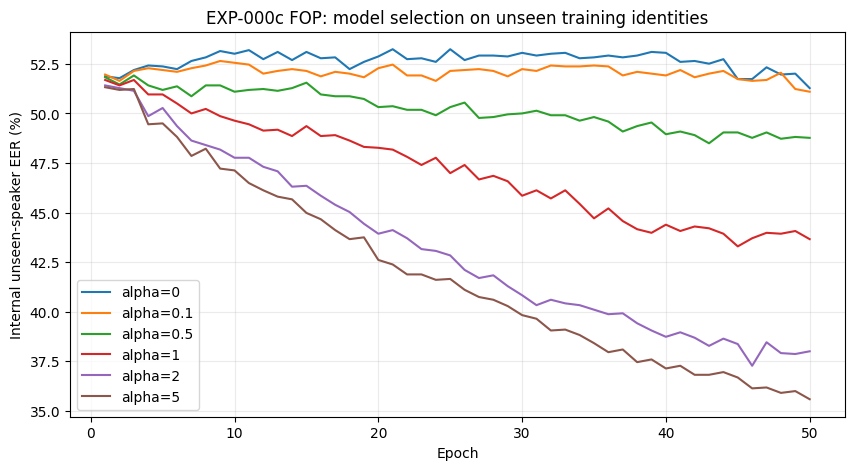

In [15]:
history_df = pd.DataFrame(all_histories)

plt.figure(figsize=(10, 5))
for alpha in sorted(history_df["alpha"].unique()):
    h = history_df[history_df["alpha"] == alpha]
    plt.plot(h["epoch"], 100*h["val_eer"], label=f"alpha={alpha:g}")

plt.xlabel("Epoch")
plt.ylabel("Internal unseen-speaker EER (%)")
plt.title("EXP-000c FOP: model selection on unseen training identities")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. Retrain the selected FOP setup on all 70 FLAG training identities

Once `alpha` and epoch are selected using unseen internal speakers, retrain from scratch on all 70 identities for exactly that many epochs.

This gives a final model that uses all available official training data without touching withheld FLAG dev labels.

In [16]:
all_classes = sorted(np.unique(face_labels_raw).tolist())
all_class_to_idx = {s: i for i, s in enumerate(all_classes)}
y_all = np.asarray([all_class_to_idx[s] for s in face_labels_raw], dtype=np.int64)

def train_final_model(alpha, epochs):
    seed_everything(cfg.SEED)

    model = make_model(num_classes=len(all_classes))
    optimizer = make_optimizer(model)

    ce_loss = nn.CrossEntropyLoss().to(DEVICE)
    opl_loss = OrthogonalProjectionLoss().to(DEVICE)

    loader = make_loader(
        X_face, X_voice, y_all,
        batch_size=cfg.BATCH_SIZE,
        seed=cfg.SEED,
    )

    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        loss_sum = ce_sum = opl_sum = 0.0
        n_batches = 0

        pbar = tqdm(loader, desc=f"FINAL epoch={epoch:02d}/{epochs}")

        for face, voice, labels in pbar:
            face = face.to(DEVICE, non_blocking=True)
            voice = voice.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            comb, _, _ = model.train_forward(face, voice, labels)

            loss_opl, s_fac, d_fac = opl_loss(comb[0], labels)
            loss_soft = ce_loss(comb[1], labels)
            loss = loss_soft + alpha * loss_opl

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            loss_sum += float(loss.item())
            ce_sum += float(loss_soft.item())
            opl_sum += float(loss_opl.item())
            n_batches += 1

        history.append({
            "epoch": epoch,
            "loss": loss_sum/n_batches,
            "ce": ce_sum/n_batches,
            "opl": opl_sum/n_batches,
        })

        print(
            f"FINAL epoch={epoch:02d} "
            f"loss={history[-1]['loss']:.4f} "
            f"ce={history[-1]['ce']:.4f} "
            f"opl={history[-1]['opl']:.4f}"
        )

    return model, history

final_model, final_history = train_final_model(
    SELECTED_ALPHA,
    SELECTED_EPOCH,
)

FINAL_CKPT = RUN_DIR / "final_fop.pt"
torch.save({
    "state_dict": final_model.state_dict(),
    "selected_alpha": SELECTED_ALPHA,
    "selected_epoch": SELECTED_EPOCH,
    "internal_val_eer_percent": SELECTED_INTERNAL_EER,
    "config": asdict(cfg),
    "face_dim": 4096,
    "voice_dim": 192,
    "num_classes": 70,
}, FINAL_CKPT)

print("Saved:", FINAL_CKPT)

FINAL epoch=01/50:   0%|          | 0/50 [00:00<?, ?it/s]

FINAL epoch=01 loss=8.2513 ce=4.2575 opl=0.7987


FINAL epoch=02/50:   0%|          | 0/50 [00:00<?, ?it/s]

FINAL epoch=02 loss=8.2363 ce=4.2544 opl=0.7964


FINAL epoch=03/50:   0%|          | 0/50 [00:00<?, ?it/s]

...

FINAL epoch=48 loss=7.3492 ce=4.1711 opl=0.6356


FINAL epoch=49/50:   0%|          | 0/50 [00:00<?, ?it/s]

FINAL epoch=49 loss=7.3158 ce=4.1689 opl=0.6294


FINAL epoch=50/50:   0%|          | 0/50 [00:00<?, ?it/s]

FINAL epoch=50 loss=7.3009 ce=4.1670 opl=0.6268
Saved: /kaggle/working/FLAG_2027_EXP-000c-source-faithful/final_fop.pt


## 10. Sanity diagnostics — seen vs unseen

The key diagnostic is not just whether the model fits seen speakers.

We report:
- **seen-train** balanced verification EER
- **internal unseen-speaker** EER from the selected model during the sweep

If seen EER is low but unseen EER is ~50%, the system is still memorizing speaker identities and should not be submitted.

In [17]:
TRAIN_PAIR_FACE, TRAIN_PAIR_VOICE, TRAIN_PAIR_Y = build_balanced_verification_pairs(
    X_face, X_voice, face_labels_raw, seed=cfg.SEED + 17
)

train_face_emb, train_voice_emb = verification_embeddings(
    final_model,
    TRAIN_PAIR_FACE,
    TRAIN_PAIR_VOICE,
)
train_similarity = internal_similarity_from_embeddings(train_face_emb, train_voice_emb)
train_eer, _ = compute_eer_from_similarity(TRAIN_PAIR_Y, train_similarity)
train_auc = roc_auc_score(TRAIN_PAIR_Y, train_similarity)

diagnostic_df = pd.DataFrame([
    {
        "metric": "seen-train verification",
        "EER_%": 100*train_eer,
        "AUC": train_auc,
    },
    {
        "metric": "internal unseen-speaker selection",
        "EER_%": SELECTED_INTERNAL_EER,
        "AUC": float(best_row["best_val_AUC"]),
    },
])

display(diagnostic_df)

if SELECTED_INTERNAL_EER >= 45:
    raise RuntimeError(
        "Internal unseen-speaker EER is near random. "
        "Do NOT submit; baseline generalization is still broken."
    )

print("✅ Internal unseen-speaker verification is meaningfully better than random.")

,metric,EER_%,AUC
0,seen-train verification,10.208173,0.963678
1,internal unseen-speaker selection,35.583942,0.696838


✅ Internal unseen-speaker verification is meaningfully better than random.


## Validated scorer conflict

The Evaluation Plan text says a higher score should mean a stronger match, but the live CodaBench progress scorer has been empirically demonstrated to produce the correct/lower EER only when raw FOP distances are submitted.

For current experiments, **live scorer behavior takes operational precedence**:

```text
submit +squared_L2
lower value = stronger match
```

If organizers later change the scorer, revalidate this before final evaluation.

## 11. Generate official FLAG development score files

In [18]:
def read_pair_keys(path: Path):
    keys = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) < 3:
                raise ValueError(f"{path}:{line_no}: malformed pair row")
            keys.append(parts[0])

    if len(keys) != len(set(keys)):
        raise ValueError(f"Duplicate pair IDs in {path}")
    return keys


SUBMISSION_DIR = RUN_DIR / "submission"
if SUBMISSION_DIR.exists():
    shutil.rmtree(SUBMISSION_DIR)
SUBMISSION_DIR.mkdir(parents=True)

score_stats = []

for track, lang, out_name, expected_n in PROTOCOLS:
    p = resolved_protocols[(track, lang)]

    face = pd.read_csv(p["face"], header=None).to_numpy(dtype=np.float32)
    voice = pd.read_csv(p["voice"], header=None).to_numpy(dtype=np.float32)
    keys = read_pair_keys(p["pairs"])

    assert len(face) == len(voice) == len(keys) == expected_n

    face_emb, voice_emb = verification_embeddings(final_model, face, voice)
    scores = codabench_submission_score(face_emb, voice_emb)

    out_dir = SUBMISSION_DIR / track
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / out_name

    with out_path.open("w", encoding="utf-8", newline="\n") as f:
        for key, score in zip(keys, scores):
            f.write(f"{key} {float(score):.10f}\n")

    score_stats.append({
        "track": track,
        "language": lang,
        "n": len(scores),
        "mean": float(scores.mean()),
        "std": float(scores.std()),
        "min": float(scores.min()),
        "max": float(scores.max()),
        "file": str(out_path),
    })

display(pd.DataFrame(score_stats))
print("\n✅ Submission values are RAW positive squared-L2 distances.")
print("✅ Current validated CodaBench convention: LOWER = more likely same speaker.")

,track,language,n,mean,std,min,max,file
0,no_gender,English,1008,1.283760,0.158285,0.781264,1.748842,/kaggle/working/FLAG_2027_EXP-000c-source-fait...
1,no_gender,Bangla,1406,1.278613,0.173571,0.706951,1.744785,/kaggle/working/FLAG_2027_EXP-000c-source-fait...
2,gender,English,982,1.259783,0.149653,0.684074,1.676485,/kaggle/working/FLAG_2027_EXP-000c-source-fait...
3,gender,Bangla,1468,1.247495,0.161289,0.627094,1.747614,/kaggle/working/FLAG_2027_EXP-000c-source-fait...



✅ Submission values are RAW positive squared-L2 distances.
✅ Current validated CodaBench convention: LOWER = more likely same speaker.


## 12. Strict submission validation and ZIP

In [19]:
EXPECTED_LAYOUT = {
    "no_gender": [
        "sub_score_v4_English_heard.txt",
        "sub_score_v4_Bangla_unheard.txt",
    ],
    "gender": [
        "sub_score_v4_English_heard.txt",
        "sub_score_v4_Bangla_unheard.txt",
    ],
}

def validate_score_file(path):
    keys = []
    vals = []

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            parts = line.strip().split()
            if len(parts) != 2:
                raise ValueError(f"{path}:{line_no}: expected '<key> <score>'")

            key, score_raw = parts
            score = float(score_raw)

            if not np.isfinite(score):
                raise ValueError(f"{path}:{line_no}: non-finite score")

            keys.append(key)
            vals.append(score)

    if len(keys) != len(set(keys)):
        raise ValueError(f"Duplicate keys in {path}")

    return len(keys)

for track, names in EXPECTED_LAYOUT.items():
    actual = sorted(p.name for p in (SUBMISSION_DIR / track).iterdir() if p.is_file())
    assert actual == sorted(names), (track, actual)

    for name in names:
        n = validate_score_file(SUBMISSION_DIR / track / name)
        print(f"✅ {track}/{name}: {n} rows")

if cfg.FAST_DEV_RUN:
    ZIP_PATH = RUN_DIR / "DO_NOT_SUBMIT_FAST_EXP000c_distance.zip"
else:
    ZIP_PATH = RUN_DIR / "submission_EXP000c_VALIDATED_DISTANCE.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for track, names in EXPECTED_LAYOUT.items():
        for name in names:
            src = SUBMISSION_DIR / track / name
            zf.write(src, arcname=f"{track}/{name}")

print("ZIP:", ZIP_PATH)
if cfg.FAST_DEV_RUN:
    print("🛑 FAST_DEV_RUN=True — do not submit this archive.")
else:
    print("✅ Full EXP-000c archive ready for CodaBench.")

✅ no_gender/sub_score_v4_English_heard.txt: 1008 rows
✅ no_gender/sub_score_v4_Bangla_unheard.txt: 1406 rows
✅ gender/sub_score_v4_English_heard.txt: 982 rows
✅ gender/sub_score_v4_Bangla_unheard.txt: 1468 rows
ZIP: /kaggle/working/FLAG_2027_EXP-000c-source-faithful/submission_EXP000c_VALIDATED_DISTANCE.zip
✅ Full EXP-000c archive ready for CodaBench.


## 13. Save experiment metadata

After CodaBench returns the four EERs, fill those values into the metadata before syncing the experiment.

In [20]:
metadata = {
    "experiment_id": cfg.EXP_ID,
    "source_basis": [
        "Fusion and Orthogonal Projection for Improved Face-Voice Association (ICASSP 2022)",
        "https://github.com/msaadsaeed/FOP",
        "https://github.com/SwapnilKhandoker101/FLAG_2027",
        "https://mavceleb.github.io/dataset/competition.html",
    ],
    "config": asdict(cfg),
    "selected_alpha": SELECTED_ALPHA,
    "selected_epoch": SELECTED_EPOCH,
    "internal_unseen_eer_percent": SELECTED_INTERNAL_EER,
    "final_checkpoint": str(FINAL_CKPT),
    "submission_zip": str(ZIP_PATH),
    "score_stats": score_stats,
    "validated_score_orientation": {
        "submission_score": "raw positive squared L2 distance",
        "interpretation": "lower = more likely same speaker",
        "negative_distance_overall_eer": 57.83,
        "raw_distance_overall_eer": 42.17,
        "raw_distance_cells": {
            "no_gender_English": 36.31,
            "no_gender_Bangla": 38.98,
            "gender_English": 43.38,
            "gender_Bangla": 50.00
        }
    },
    "codabench": {
        "no_gender_English": None,
        "no_gender_Bangla": None,
        "gender_English": None,
        "gender_Bangla": None,
        "overall": None,
    },
    "notes": (
        "Source-faithful FOP architecture/loss. "
        "Model selection uses speaker-disjoint internal validation because public FLAG dev GT is withheld. "
        "Live CodaBench was empirically validated to require raw positive squared-L2 distance (lower=same)."
    ),
}

metadata_path = RUN_DIR / "run_metadata_EXP000c.json"
metadata_path.write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Saved:", metadata_path)

Saved: /kaggle/working/FLAG_2027_EXP-000c-source-faithful/run_metadata_EXP000c.json


# Run checklist — validated baseline

For a quick execution test:

```python
FAST_DEV_RUN = True
```

For the real baseline:

```python
FAST_DEV_RUN = False
```

Before submission confirm:

- [ ] all 6 alphas were evaluated
- [ ] model selection used unseen internal speakers
- [ ] internal unseen-speaker EER is clearly below 45%
- [ ] final model was retrained on all 70 identities
- [ ] submission contains exactly four files
- [ ] **submission values are raw positive squared-L2 distances**
- [ ] **do not negate the distance**
- [ ] current live CodaBench convention is treated as `LOWER = same`

## Validated CodaBench baseline

Using raw squared-L2 distance:

- no_gender English: **36.31**
- no_gender Bangla: **38.98**
- gender English: **43.38**
- gender Bangla: **50.00**
- Overall: **42.17**

Organizer FOP Dev reference:

- no_gender English: `32.54`
- no_gender Bangla: `38.12`
- gender English: `32.99`
- gender Bangla: `44.01`
- Overall: `36.92`

So this notebook is now the **validated operational baseline**, while there remains a ~5.25 EER-point gap to the organizer reference.